<a href="https://colab.research.google.com/github/AsyrofiAnam/DeepLearning/blob/main/Yolo_Alat_Pembersih_Rumah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.139 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.6/112.6 GB disk)


In [2]:
from ultralytics import YOLO

# model YOLOv8n
model = YOLO("yolov8n.pt")

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="QW5yaebJDunZp2I0xvHE")
project = rf.workspace("tugas-4-deep-learning").project("alatpembersihrumah")
version = project.version(4)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to AlatPembersihRumah-4 in yolov8:: 100%|██████████| 2652/2652 [00:00<00:00, 5336.19it/s]


In [4]:
# Training
!yolo task=detect mode=train model=yolov8n.pt data=/content/AlatPembersihRumah-4/data.yaml epochs=50 imgsz=640

Ultralytics 8.3.139 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/AlatPembersihRumah-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0,

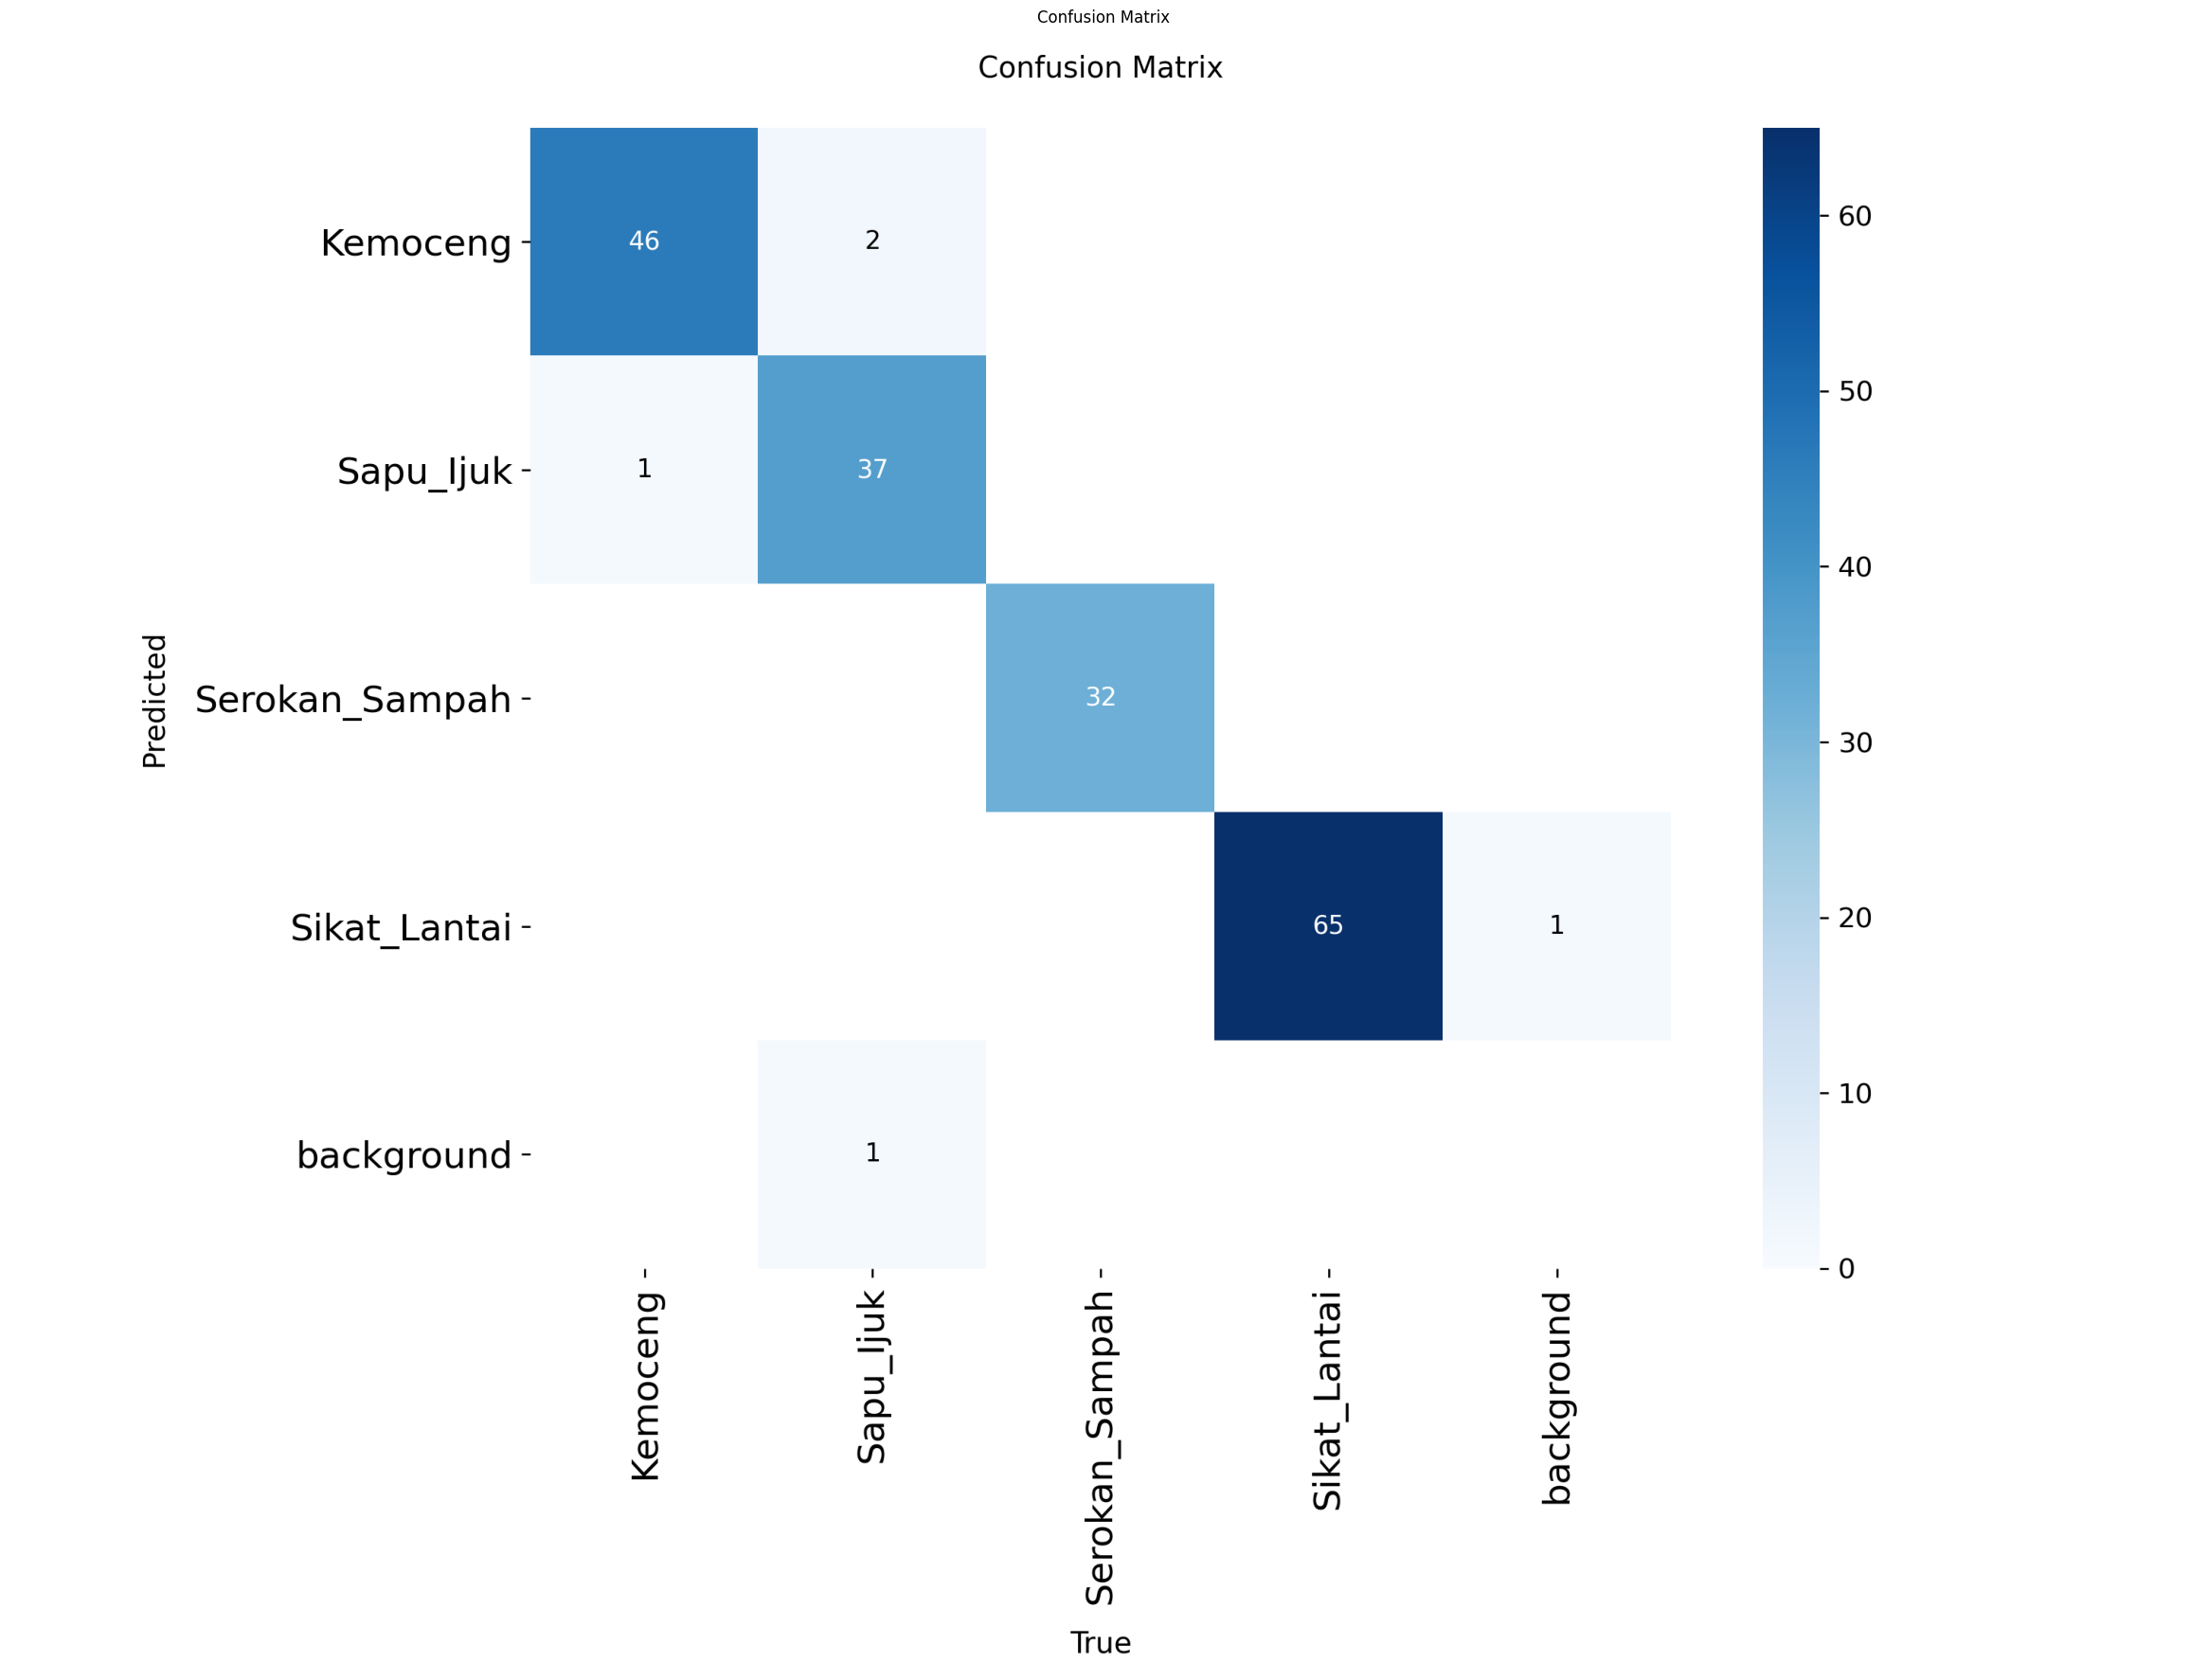

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/content/runs/detect/train/confusion_matrix.png"
img = Image.open(img_path)

w, h = img.size
dpi = 100

plt.figure(figsize=(w/dpi, h/dpi), dpi=dpi)
plt.imshow(img)
plt.axis('off')
plt.title("Confusion Matrix", fontsize=12)
plt.show()

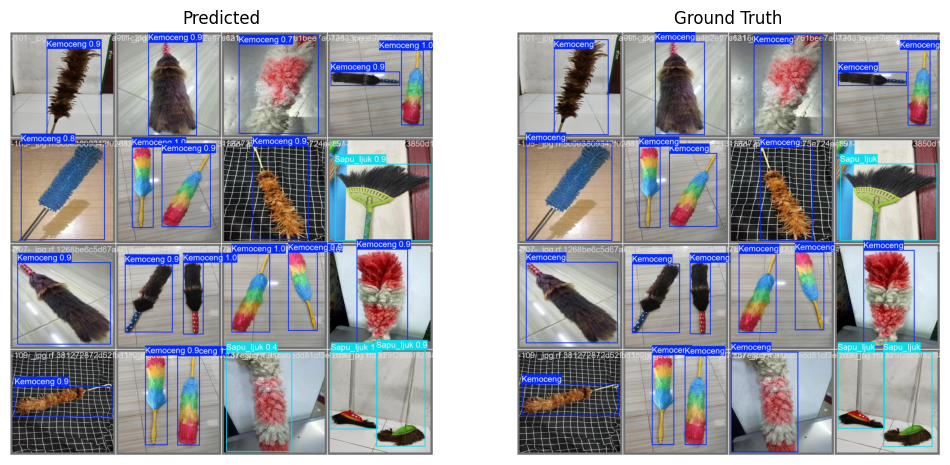

In [6]:
pred = Image.open("runs/detect/train/val_batch0_pred.jpg")
labels = Image.open("runs/detect/train/val_batch0_labels.jpg")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(pred)
plt.axis('off')
plt.title("Predicted")

plt.subplot(1, 2, 2)
plt.imshow(labels)
plt.axis('off')
plt.title("Ground Truth")

plt.show()

In [7]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")  # model hasil training

# Prediksi 10 gambar
results_img = model.predict(source="/content/drive/MyDrive/test_images", save=True, verbose=False)

# Prediksi video
results_vid = model.predict(source="/content/drive/MyDrive/test_video.mp4", save=True, verbose=False)

Results saved to runs/detect/predict
WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to runs/detect/predict


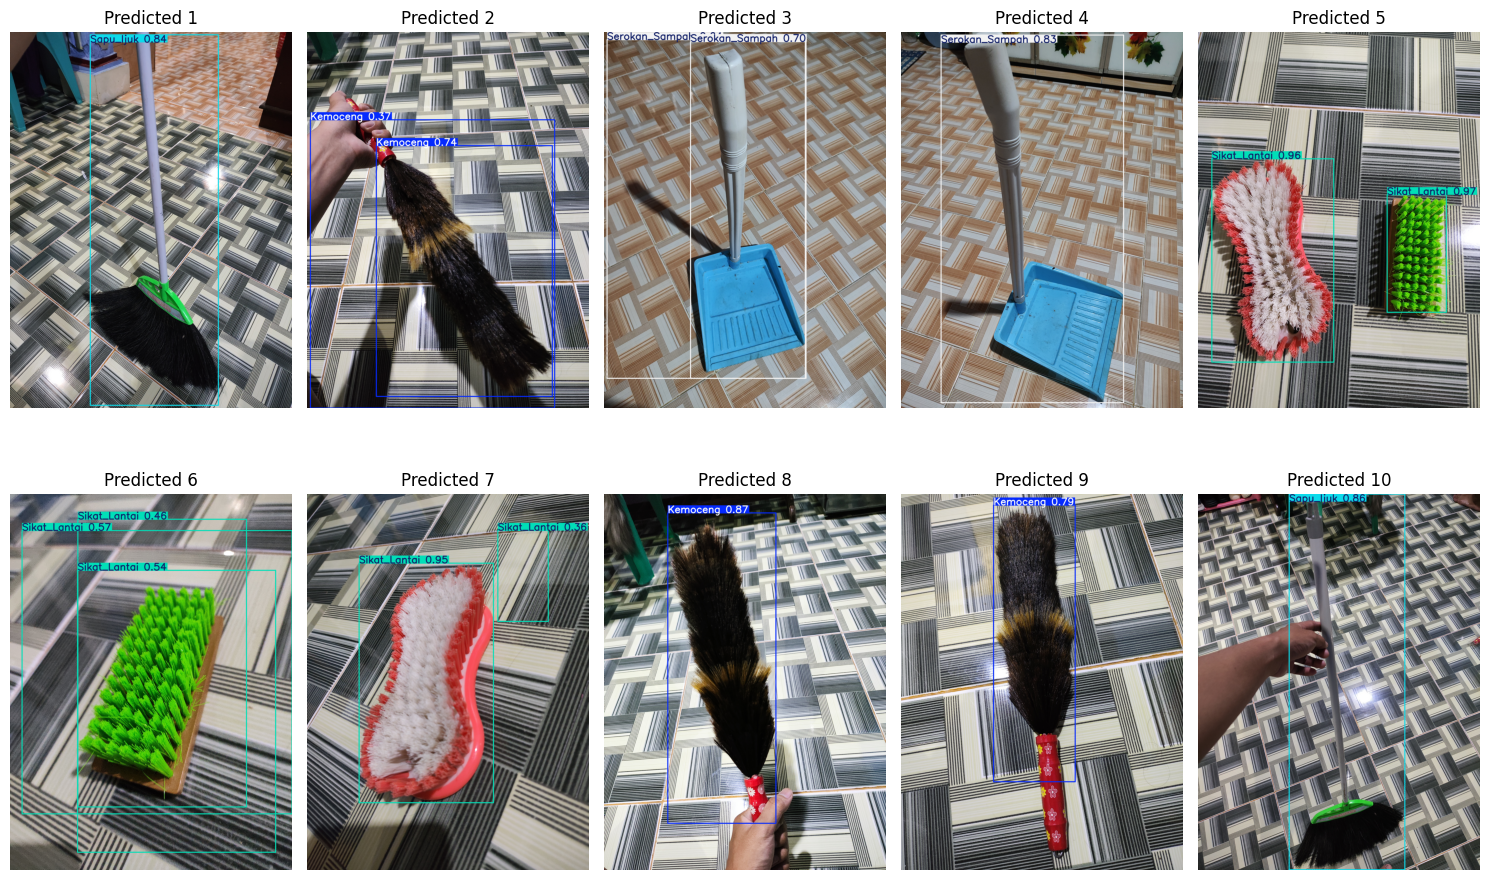

In [8]:
import glob

predicted_images = glob.glob("runs/detect/predict/*.jpg")

plt.figure(figsize=(15, 10))
for i, img_path in enumerate(predicted_images[:10]):
    img = Image.open(img_path)
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted {i+1}")
plt.tight_layout()
plt.show()

In [9]:
from IPython.display import HTML
from base64 import b64encode

# download video dari url berikut
video_url = "https://github.com/AsyrofiAnam/DeepLearning/raw/refs/heads/main/test_video..mp4"

HTML(f"""
<video width="640" height="480" controls>
  <source src="{video_url}" type="video/mp4">
</video>
""")